# Logistic Regression
- Examination of the odds ratios and features.

- Features and References:
    - Log2-transformed gross_approval
        - No reference
    - term_in_months split into 6 bins. 
        - Ref: 61-84mo
    - revolver_status. 
        - Ref: non-revolver (0)
    - collateral_ind. 
        - Ref: unsecured (0)
    - naics_sector_description.
        - Ref: Construction

In [13]:
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression # Used for cross_val_score, penalty = None
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats

load_dotenv()
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
name = os.getenv('DB_NAME')
user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')

engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{name}")
df_model = pd.read_sql_table('vw_loans_model', engine, schema = 'sba')

In [14]:
# Ensure rows equal 348,271. Rows decreased by 3 from the EDA notebook since loans with NULL in collateral_ind have been removed

assert df_model.shape[0] == 348_271, f"Expected 348,271 rows, got {df_model.shape[0]}"

In [15]:
df_model.columns

Index(['loan_id', 'loan_status', 'is_default', 'gross_approval',
       'approval_fiscal_year', 'term_in_months', 'two_digit_naics_sector',
       'naics_sector_description', 'naics_code', 'naics_description',
       'revolver_status', 'jobs_supported', 'approval_date', 'collateral_ind',
       'term_bin'],
      dtype='str')

In [16]:
# Ensure default rate matches that of the EDA notebook

portfolio_default_rate = np.round(np.mean(df_model['is_default']) * 100, 2)

assert portfolio_default_rate == 7.54, f"Expected Default Rate of 7.54%, got {portfolio_default_rate} %"

In [17]:
""" Transforming to log because the data is right skewed.
Using log2 so that each unit increase represents a doubling of the original value. 
Easier to explain than ln, which would result in the original value being multiplied by the power of Euler's number. """

df_model['log_gross_approval'] = np.log2(df_model['gross_approval'])
df_model[['gross_approval', 'log_gross_approval']].describe()

,gross_approval,log_gross_approval
count,3.482710e+05,348271.000000
mean,3.242990e+05,16.735193
std,6.002574e+05,2.167045
min,1.000000e+03,9.965784
25%,3.350000e+04,15.031873
50%,1.000000e+05,16.609640
75%,3.250000e+05,18.310080
max,5.000000e+06,22.253497


In [18]:
# Set 25% of data for testing and the remainder for training. Use stratify to keep the default rate equal between train and test sets.

train, test = train_test_split(df_model, stratify = df_model[['is_default']], test_size = 0.25, random_state = 123)

During the first attempt to run the logit, the model was failing to converge without the method being changed to BFGS and the maxiter limit increased to 500. After converging, I pulled the parameters and saw that the 301-324mo term bucket displayed a coefficient of -8.35, which was a significant outlier, likely due to sparse data. To eliminate the outlier, the 241-300mo and 301-324mo buckets have been merged.

In [19]:
default_rate_mdl = smf.logit(
    'is_default ~ log_gross_approval '
    '+ C(naics_sector_description, Treatment(reference = "Construction")) '
    '+ revolver_status + collateral_ind '
    '+ C(term_bin, Treatment(reference = "61-84mo"))',
    data = train
).fit()

Optimization terminated successfully.
         Current function value: 0.237998
         Iterations 8


In [20]:
default_rate_mdl.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             is_default   No. Observations:               261203
Model:                          Logit   Df Residuals:                   261176
Method:                           MLE   Df Model:                           26
Date:                Sat, 08 Aug 2026   Pseudo R-squ.:                  0.1096
Time:                        09:41:56   Log-Likelihood:                -62166.
converged:                       True   LL-Null:                       -69816.
Covariance Type:            nonrobust   LLR p-value:                     0.000
================================================================================================================================================================================================================
                                                                                                                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                                                                       -4.5640      0.081    -56.387      0.000      -4.723      -4.405
C(naics_sector_description, Treatment(reference="Construction"))[T.Accommodation and Food Services]                                              0.3729      0.032     11.790      0.000       0.311       0.435
C(naics_sector_description, Treatment(reference="Construction"))[T.Administrative and Support and Waste Management and Remediation Services]    -0.0926      0.043     -2.147      0.032      -0.177      -0.008
C(naics_sector_description, Treatment(reference="Construction"))[T.Agriculture, Forestry, Fishing and Hunting]                                  -0.5065      0.074     -6.837      0.000      -0.652      -0.361
C(naics_sector_description, Treatment(reference="Construction"))[T.Arts, Entertainment, and Recreation]                                          0.4394      0.048      9.227      0.000       0.346       0.533
C(naics_sector_description, Treatment(reference="Construction"))[T.Educational Services]                                                         0.2128      0.069      3.068      0.002       0.077       0.349
C(naics_sector_description, Treatment(reference="Construction"))[T.Finance and Insurance]                                                       -0.4575      0.080     -5.705      0.000      -0.615      -0.300
C(naics_sector_description, Treatment(reference="Construction"))[T.Health Care and Social Assistance]                                           -0.2109      0.038     -5.525      0.000      -0.286      -0.136
C(naics_sector_description, Treatment(reference="Construction"))[T.Information]                                                                  0.0159      0.072      0.221      0.825      -0.125       0.157
C(naics_sector_description, Treatment(reference="Construction"))[T.Management of Companies and Enterprises]                                     -1.2383      0.591     -2.097      0.036      -2.396      -0.081
C(naics_sector_description, Treatment(reference="Construction"))[T.Manufacturing]                                                               -0.1462      0.037     -3.963      0.000      -0.218      -0.074
C(naics_sector_description, Treatment(reference="Construction"))[T.Mining, Quarrying, and Oil and Gas Extraction]                               -0.4633      0.149     -3.113      0.002      -0.755      -0.172
C(naics_sector_description, Treatment(reference="Construction"))[T.Other Services (except Public Administr

### Empirical Check for Log_gross_approval
- Determine whether relationship is linear or contains clear curvature.

In [21]:
# Creating term quantiles

train['quantile_log_gross_approval'] = pd.qcut(df_model['log_gross_approval'], 15)
train['quantile_log_gross_approval'].value_counts()


quantile_log_gross_approval
(15.988, 16.61]     29019
(15.202, 15.61]     27686
(16.873, 17.195]    20301
(14.288, 14.61]     19547
(13.288, 14.288]    19120
(17.729, 18.195]    18678
(9.965, 13.288]     17912
(18.616, 19.31]     17709
(20.204, 22.253]    17452
(19.31, 20.204]     17092
(18.195, 18.616]    16086
(17.195, 17.729]    14383
(14.61, 15.202]     13231
(15.61, 15.988]      7677
(16.61, 16.873]      5310
Name: count, dtype: int64

In [22]:
# Calculate average default rate and loan size along with log-odds of default

loan_size_check = train.groupby('quantile_log_gross_approval')[['is_default', 'log_gross_approval']].agg('mean').sort_index(ascending = True)
loan_size_check['log_odds'] = np.log(loan_size_check['is_default'] / (1 - loan_size_check['is_default']))
loan_size_check

,is_default,log_gross_approval,log_odds
quantile_log_gross_approval,,,
"(9.965, 13.288]",0.104399,12.982036,-2.149272
"(13.288, 14.288]",0.081015,14.019868,-2.428640
"(14.288, 14.61]",0.084361,14.590604,-2.384520
"(14.61, 15.202]",0.069836,14.934722,-2.589211
"(15.202, 15.61]",0.075200,15.531822,-2.509420
"(15.61, 15.988]",0.067214,15.832712,-2.630298
"(15.988, 16.61]",0.071436,16.423950,-2.564838
"(16.61, 16.873]",0.072881,16.764871,-2.543249
"(16.873, 17.195]",0.099601,17.127750,-2.201666


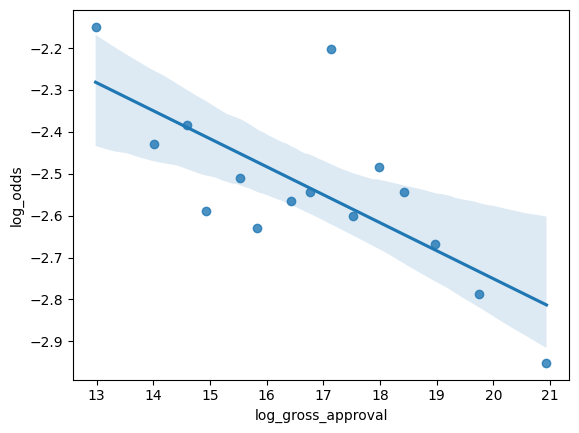

In [23]:
sns.regplot(data = loan_size_check, x = 'log_gross_approval', y = 'log_odds')
plt.show()

Empirical logit check for log_gross_approval shows a generally linear trend with no systematic curvature, supporting the decision to use the feature log-transformed rather than binned or polynomial. The trend is negative, in line with EDA expectations. This graph uses the actual outcomes in the training data rather than the output of the fitted model, so other features are not being held constant.

In [24]:
def var_names(col):
    return (col
    .str.replace('C(naics_sector_description, Treatment(reference="Construction"))[T.', "")
    .str.replace('C(term_bin, Treatment(reference="61-84mo"))[T.', "")
    .str.replace('revolver_status[T.True]', 'revolver_status')
    .str.replace(']', "")
    )

X_vif = pd.DataFrame()
X_vif['Variables'] = var_names(pd.Series(default_rate_mdl.model.exog_names))
X_vif['VIF'] = np.round([variance_inflation_factor(default_rate_mdl.model.exog, i) for i in range(X_vif.shape[0])], 2)
X_vif = X_vif.sort_values(by = 'VIF', ascending = False)
X_vif = X_vif.set_index('Variables')
X_vif

,VIF
Variables,
Intercept,118.75
Retail Trade,2.05
log_gross_approval,2.02
Accommodation and Food Services,2.00
241-324mo,1.92
85-120mo,1.87
"Professional, Scientific, and Technical Services",1.78
revolver_status,1.76
Health Care and Social Assistance,1.76


In [25]:
train.columns

Index(['loan_id', 'loan_status', 'is_default', 'gross_approval',
       'approval_fiscal_year', 'term_in_months', 'two_digit_naics_sector',
       'naics_sector_description', 'naics_code', 'naics_description',
       'revolver_status', 'jobs_supported', 'approval_date', 'collateral_ind',
       'term_bin', 'log_gross_approval', 'quantile_log_gross_approval'],
      dtype='str')

In [26]:
# Pull default rate and sample size for all NAICS sectors

def aggregate(col, df):
    agg = df.groupby(col)['is_default'].agg(['mean', 'count'])
    agg['mean'] = np.round(agg['mean'] * 100, 2)
    agg = agg.rename(columns = {'mean': 'Default Rate', 'count': 'Sample Size (Loan Count)'})
    return agg

sector_agg = aggregate('naics_sector_description', train)
sector_agg

,Default Rate,Sample Size (Loan Count)
naics_sector_description,,
Accommodation and Food Services,8.85,32273
Administrative and Support and Waste Management and Remediation Services,7.28,12039
"Agriculture, Forestry, Fishing and Hunting",4.86,4609
"Arts, Entertainment, and Recreation",10.12,7052
Construction,7.80,27418
Educational Services,7.96,3466
Finance and Insurance,4.30,4307
Health Care and Social Assistance,5.13,24299
Information,7.54,3301


In [27]:
# Repeat for term

term_agg = aggregate('term_bin', train)
term_agg

,Default Rate,Sample Size (Loan Count)
term_bin,,
0-60mo,19.51,57889
121-240mo,4.26,19647
241-324mo,1.72,28346
61-84mo,3.77,99867
85-120mo,5.94,55454


In [28]:
# Repeat for revolver status. Only True is included in the model, since False is the comparator, so False will be removed.

revolver_agg = aggregate('revolver_status', train)
revolver_agg = revolver_agg.drop(index = False)
revolver_agg = revolver_agg.rename(index = {True: 'revolver_status'})
revolver_agg

,Default Rate,Sample Size (Loan Count)
revolver_status,,
revolver_status,6.97,86563


In [29]:
# Repeat for collateral indicator. Only True (1) is included in the model, so 0 will be removed.

coll_agg = aggregate('collateral_ind', train)
coll_agg = coll_agg.drop(index = 0)
coll_agg = coll_agg.rename(index = {1: 'collateral_ind'})
coll_agg

,Default Rate,Sample Size (Loan Count)
collateral_ind,,
collateral_ind,6.78,184937


In [30]:
# Concatenate all defaults rates and sample sizes

aggs_concat = pd.concat([sector_agg, term_agg, revolver_agg, coll_agg])
aggs_concat

,Default Rate,Sample Size (Loan Count)
Accommodation and Food Services,8.85,32273
Administrative and Support and Waste Management and Remediation Services,7.28,12039
"Agriculture, Forestry, Fishing and Hunting",4.86,4609
"Arts, Entertainment, and Recreation",10.12,7052
Construction,7.80,27418
Educational Services,7.96,3466
Finance and Insurance,4.30,4307
Health Care and Social Assistance,5.13,24299
Information,7.54,3301
Management of Companies and Enterprises,2.01,149


In [31]:
# Develop summary table. Intercept is intentionally excluded. 
# No default rate or sample size is reported for log_gross_approval since it would reflect the entire portfolio. 
# The Raw Default Rate is unadjusted while the other columns in this table hold all other variables constant

conf_int = default_rate_mdl.conf_int()

summary_table = pd.DataFrame({
    'Odds Ratio': np.exp(default_rate_mdl.params),
    'Lower CI': np.exp(conf_int[0]),
    'Upper CI': np.exp(conf_int[1]),
    'P-Value': default_rate_mdl.pvalues,
})

summary_table.index = var_names(pd.Series(default_rate_mdl.model.exog_names))
summary_table = np.round(summary_table.drop(index = 'Intercept'), 3)
summary_table = pd.merge(left = summary_table, right = X_vif, how = 'left', left_index = True, right_index = True)

summary_table = pd.merge(summary_table, aggs_concat, how = 'left', left_index = True, right_index = True)
summary_table = summary_table.rename(columns = {'Default Rate': 'Raw Default Rate'})
summary_table

,Odds Ratio,Lower CI,Upper CI,P-Value,VIF,Raw Default Rate,Sample Size (Loan Count)
Accommodation and Food Services,1.452,1.365,1.545,0.000,2.00,8.85,32273.0
Administrative and Support and Waste Management and Remediation Services,0.912,0.838,0.992,0.032,1.38,7.28,12039.0
"Agriculture, Forestry, Fishing and Hunting",0.603,0.521,0.697,0.000,1.17,4.86,4609.0
"Arts, Entertainment, and Recreation",1.552,1.414,1.704,0.000,1.24,10.12,7052.0
Educational Services,1.237,1.080,1.417,0.002,1.12,7.96,3466.0
Finance and Insurance,0.633,0.541,0.741,0.000,1.15,4.30,4307.0
Health Care and Social Assistance,0.810,0.751,0.873,0.000,1.76,5.13,24299.0
Information,1.016,0.882,1.170,0.825,1.11,7.54,3301.0
Management of Companies and Enterprises,0.290,0.091,0.922,0.036,1.01,2.01,149.0
Manufacturing,0.864,0.804,0.929,0.000,1.66,6.73,21299.0


In [32]:
# Data in Summary Table above is compared to the references below

construction = sector_agg[sector_agg.index == 'Construction']
coll_0 = aggregate('collateral_ind', train).drop(index = 1).rename(index = {0: 'False collateral_ind'})
revolver_false = aggregate('revolver_status', train).drop(index = True).rename(index = {False: 'False revolver_status'})
term_61_84 = term_agg[term_agg.index == '61-84mo'].rename(index = {'61-84mo': '61-84mo Term'})

pd.concat([construction, coll_0, revolver_false, term_61_84]).rename(columns = {'Default Rate': 'Raw Default Rate'})

,Raw Default Rate,Sample Size (Loan Count)
Construction,7.80,27418
False collateral_ind,9.37,76266
False revolver_status,7.82,174640
61-84mo Term,3.77,99867


The default rates are marginally, meaning they are pulled from the raw training data and other features are not held constant. The other fields are pulling conditional data, that is, data pulled from the model where other features are held constant. Log_gross_approval does not have the Raw Default Rate or Sample Size reported since they would reflect the whole portfolio.

Reference categories have an odds ratio of 1.

### Log Gross Approval

- Interestingly, log_gross_approval's odds ratio of 1.11 indicates the odds of default increases by 11% for every doubling in loan size. In EDA, we found the opposite effect; default rate decreases as loan size increases. The CI band of 1.098-1.119 is tight and the p-value is less than 0.001, indicating loan size's effect on default is statistically significant.

- Term appears to be correlated with loan size according to term_size_comparison in the EDA notebook. The risk of default decreases as the term increases in length, and loan size generally increases with term length. However, since term and the other features are being held constant in the model, the odds ratio only reflects loan size without any influence from term. Term confounding with loan size could be the reason why the risk of default appeared to decrease as loan size increased in EDA.

### Revolver Status

- Loans with revolving terms carry a 14.8% lower odds of default than non-revolvers. The odds of default range from 11.5% to 18% less according to the confidence intervals. P-value is less than 0.001. The default rate is 6.97%, which is 0.85ppts below the default rate of 7.82% for non-revolvers.

### Term Bins

- The odds of default for the 0-60mo bucket are about 6x higher than the 61-84mo bucket. EDA also displayed a higher default rate for this section at nearly 20%. The low bound of the CI is about 5.89x, indicating the effect is still massive even at the low end of the range.

- By contrast, the 241-324mo bin carries a lower risk of default with an odds ratio indicating the odds of default are 71% lower than that of the 61-84mo bin. The raw default rate is 1.72%. This bin covers many real estate loans including those that are extended for construction purposes.

- The 121-240mo bin also has lower odds of default than the 61-84mo bucket.

- The 85-120mo bin has a 24% higher odds of default compared to our reference, 61-84mo, as well as a default rate of 5.94% which is 2.17ppts higher than the default rate of 3.77% for 61-84mo loans.

- All p-values are less than 0.001.

### NAICS Sectors

- Retail has 32% higher odds of default than Construction, with a CI range of 25%-41% higher. P-value is less than 0.001. Retail's raw default rate is also 0.95ppts higher than Construction's.

- In the graph titled "Mean Approval and Default Rate by NAICS Sector" in the EDA notebook, Education and Other Services showed lower risks of default than Construction. Unexpectedly, their odds ratios show 24% and 15% increased odds of default compared to Construction respectively. However, at the lower bound of their CIs, their ratios are less than 1.1:1, indicating there could be only a small difference in odds.

- In EDA, we found that Construction's default rate of 7.78% is near the portfolio mean of 7.54%. Only six other industries show higher odds of default than Construction, with Information being about equal. This suggests Construction, when all other features are held constant, displays above-average risk, which goes against my prior.

### Collateral Indicator

- Secured loans (collateral indicator = 1) have about 34% lower odds of default than unsecured loans. The CI bands are tight at 32%-37% lower odds. The raw default rate is also 2.59ppts lower than the default rate for unsecured loans.

### VIF
- No VIFs above the threshold of 2.5 were reported. Most remained under 2, well below the established threshold of 5. Even if we used a tighter threshold of 2.5, no VIFs would indicate significant overlap.

- Ultimately, there is no indication that predictor overlap is inflating standard errors (no evidence of multicollinearity).

- The intercept's VIF is not applicable.

## Priors Analysis

Looking back at my original priors, my gross_approval prior appears to be correct according to the model, despite being discredited by the EDA. Confounding variables may have contributed to this. Ultimately, the **results for my loan size prior are mixed**.

The Retail prior is my strongest and remains correct between both EDA and the model. **Retail has a higher-than-average risk of default**.

My Construction prior was marginally correct in the EDA, but appears to be incorrect according to the model. I believe it's fair to disconfirm the prior claiming that Construction is average risk. The second part of this prior, which claimed that Construction's risk of default would remain consistent amongst all levels of loan size, is not challenged by the model since it holds all other features equal. **My prior that Construction poses average risk is disconfirmed by the model, while the prior claiming that Construction will hold similar risk between loan sizes is unchallenged by the model**.

In [ ]:
# Determine model stability by assessing AUC score across 5 different folds
# C = np.inf used for unpenalized fit
# max_iter raised to 1000 because sklearn's lbfgs default (100) is insufficient for an unpenalized fit at this scale

X = default_rate_mdl.model.exog
y = default_rate_mdl.model.endog

cv_auc = cross_val_score(
    LogisticRegression(C = np.inf, max_iter = 1000),
    X, y, cv = 5, scoring = 'roc_auc'
)

print(cv_auc, cv_auc.mean())

[0.75693999 0.75321669 0.74512857 0.75217645 0.74601319] 0.7506949784810028


In [ ]:
# Calculate AUC for the model

preds = default_rate_mdl.predict(test)

fpr, tpr, thresholds = roc_curve(test['is_default'], preds)
auc = roc_auc_score(test['is_default'], preds)
auc

0.750436665854396

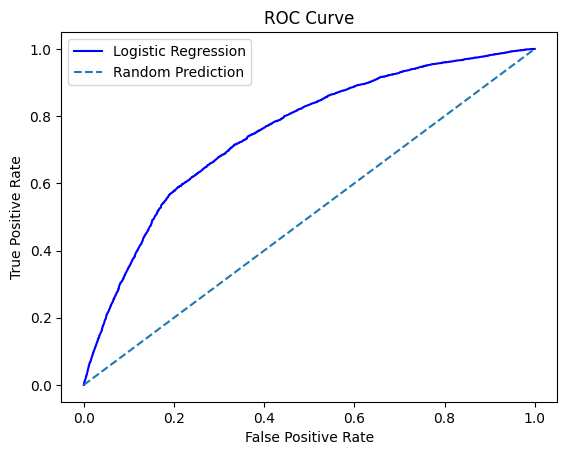

In [ ]:
# Visualize the ROC curve

plt.plot(fpr, tpr, color = 'blue', label = 'Logistic Regression')
plt.plot([0, 1], [0, 1], linestyle = '--', label = 'Random Prediction')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [ ]:
# Create calibration curve

frac_pos, mean_pred = calibration_curve(test['is_default'], preds, n_bins = 10, strategy = 'quantile')

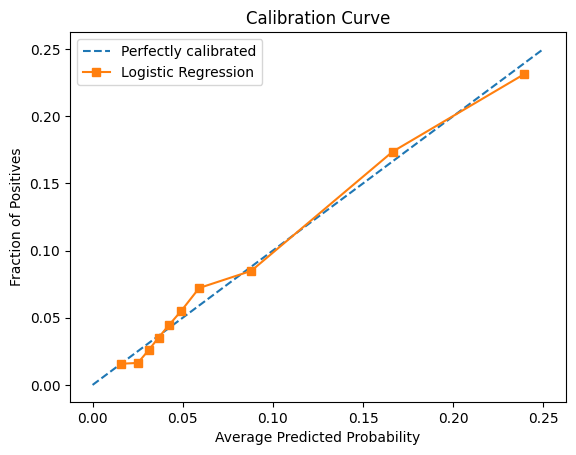

In [ ]:
# Plot calibration curve against perfect calibration

plt.plot([0, 0.25], [0, 0.25], linestyle = '--', label = 'Perfectly calibrated')
plt.plot(mean_pred, frac_pos, 's-', label='Logistic Regression')
plt.ylabel('Fraction of Positives')
plt.xlabel('Average Predicted Probability')
plt.legend()
plt.title('Calibration Curve')
plt.show()

In [38]:
np.max(preds)

np.float64(0.4254993837068893)

## Model Evaluation

- The AUC score of 0.75 indicates that the model assigns a higher predicted probability of default to a randomly chosen defaulted loan than a randomly chosen non-defaulted loan 75% of the time. The calibration curve shows that the predictions for each bin align closely to perfect calibration.

- The AUC scores across the 5 folds in the cross_val_score function were tight, ranging between 0.7451 and 0.7569. The mean of these scores, 0.7507, lines up well with the AUC Score we derived from the ROC Curve.

- The quantile strategy was used on the calibration curve so each bin holds an equal number of loans. Since 7.5% is the portfolio mean, predicted probabilities concentrate at low values, with few loans approaching the max of 42.5%. Uniform-width bins would thus leave upper bins nearly empty, causing instability.

## Limitations

- Only terminal loans, which were either Paid In Full or Charge-Offs, were included in this model. This inherently inflates default rates and can skew towards loans which were paid off early.

- Interactions for logistic regressions are complicated, and thus were excluded from the scope of the project. Certain interactions such as Revolver x Term and Gross Approval x Term are not accounted for. A presentation from UCLA indicated that interaction terms can be significant while the probability difference in differences is not significant and vice versa. So interactions could provide findings that are difficult to reconcile.
    - Source: https://stats.oarc.ucla.edu/stata/seminars/deciphering-interactions-in-logistic-regression/

- No borrower financials or credit information are available in the data.

- There is only one loan size coefficient across all NAICS sectors, so we cannot determine whether some industries display more sensitivity to loan size relative to others.

- The macroeconomic conditions are not factored in the model; the vintages span years FY2010-2017, beginning from the recovery from the 2008 crisis and the following expansionary period.

- The time horizon does not include any recessionary period, so the model may understate risk in stressed conditions.